### Logistic Regression (a type of classification) Algorithm
##### It is an extended version of Linear Regression where it converts the predicted numerical value to a probability value which is then classified as 1/0 (Yes/No)

In [104]:
import numpy as np

In [105]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [106]:
def predict(X, w, b, threshold=0.5):
    m, n = X.shape
    p = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        f = sigmoid(z)

        p[i] = 1 if f >= threshold else 0

    return p

In [107]:
def predict_probability(X, w, b):
    z = np.dot(X, w) + b
    f = sigmoid(z)

    return f

In [108]:
def compute_loss_logistic(X, y, w, b):
    cost = 0.
    m, n = X.shape

    for i in range(m):
        z = np.dot(w, X[i]) + b
        f = sigmoid(z)

        cost += (-y[i] * np.log(f)) - ((1 - y[i]) * np.log(1 - f))
    
    cost = cost / m   

    return cost

In [109]:
def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    for i in range(m):
        predicted = predict_probability(X[i], w, b)
        
        error = predicted - y[i]
        dj_dw += error * X[i]   # derivative of cost function w.r.t "w"
        dj_db += error  # # derivative of cost function w.r.t "b"

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db 

In [110]:
def gradient_descent(X, y, w, b, alpha=0.001, iterations=10000):

    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        
        w = w - alpha * dj_dw   # update weight
        b = b - alpha * dj_db   # update bias

        cost = compute_loss_logistic(X, y, w, b)
        cost_history.append(cost)

    return w, b, cost_history

In [111]:
def train(X, y):
    n = X.shape[1]
    w = np.zeros((n,))
    b = 0

    w, b, cost_history = gradient_descent(X, y, w, b)

    return w, b, cost_history



In [112]:
import pandas as pd

In [113]:
disease = pd.read_csv("disease_prediction.csv")
disease.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [114]:
disease.physical_activity.value_counts()

physical_activity
Medium    344
High      344
Low       312
Name: count, dtype: int64

In [127]:
disease.info() # mix of object, integer, and float datatypes
disease.isnull().sum() # no null values so no need to worry about filling missing values
disease.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   float64
 2   gender               1000 non-null   int64  
 3   glucose_mg_dl        1000 non-null   float64
 4   cholesterol_mg_dl    1000 non-null   float64
 5   systolic_bp          1000 non-null   float64
 6   diastolic_bp         1000 non-null   float64
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   float64
 9   smoking              1000 non-null   int64  
 10  alcohol_consumption  1000 non-null   int64  
 11  physical_activity    1000 non-null   int64  
 12  family_history       1000 non-null   int64  
 13  disease              1000 non-null   int64  
dtypes: float64(7), int64(7)
memory usage: 109.5 KB


(1000, 14)

In [116]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

encoder = LabelEncoder()
scaler = StandardScaler()

disease["gender"] = encoder.fit_transform(disease["gender"])
disease["smoking"] = encoder.fit_transform(disease["smoking"])
disease["alcohol_consumption"] = encoder.fit_transform(disease["alcohol_consumption"])
disease["family_history"] = encoder.fit_transform(disease["family_history"])
disease["disease"] = encoder.fit_transform(disease["disease"])

# encoder works well for binary classification (yes/no), (male/female)
# but here for "physical_activity" we have ordinal values (low/medium/high) and encoder is not mapping it right so we will map it manually
# encoder only accepts a single categorical feature so we have to do it for each and every feature

disease["physical_activity"] = disease["physical_activity"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

numeric_features = ["age", "glucose_mg_dl", "cholesterol_mg_dl", "systolic_bp", "diastolic_bp", "bmi", "heart_rate"]

# scaler on the other hand accepts a list of features (2D DataFrame)
disease[numeric_features] = scaler.fit_transform(disease[numeric_features])
disease.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,-0.967356,1,-0.126197,0.628907,1.503703,-0.203914,0.506108,-0.299858,0,1,0,1,1
1,2,-1.017765,1,0.791455,-0.478590,0.540717,-0.404617,1.641539,-0.501918,0,1,0,1,1
2,3,-0.312034,1,-1.881705,-1.737109,-0.529268,-1.006725,0.232763,0.306324,1,1,0,0,0
3,4,1.200247,0,-1.402930,1.459530,-0.208273,0.097140,-0.965747,-1.512220,1,1,1,0,1
4,5,0.091241,1,0.113190,-1.183360,0.380219,-0.605319,-0.587270,-0.299858,1,0,0,1,1


In [ ]:
X = disease.drop(columns=["patient_id", "disease"])
y = disease["disease"]

X = X.to_numpy()
y = y.to_numpy()

w, b, cost_history = train(X, y)
print(f"Optimal values for w and b are:")
print(f"w = {w}")
print(f"b = {b:.2f}")

Optimal values for w and b are:
w = [ 0.51759942  0.06055008  0.47203943  0.3135768   0.40042111  0.00288438
  0.38524719 -0.08332319  0.55835486  0.27101542 -0.75246691  0.56654255]
b = 0.05


In [125]:
w_tmp = np.zeros((X.shape[1],))
b_tmp = 0
total_cost = compute_loss_logistic(X, y, w_tmp, b_tmp)
print(f"Total cost with initial (non-optimal) values of w and b: {total_cost}")

total_cost = compute_loss_logistic(X, y, w, b)
print(f"Total cost with optimal values of w and b: {total_cost}")

Total cost with initial (non-optimal) values of w and b: 0.6931471805599322
Total cost with optimal values of w and b: 0.4425944790195998


In [ ]:
predicted = predict_probability(X[450], w, b)
predicted = 1 if predicted >= 0.5 else 0

print(f"Actual disease (Yes/No): {y[450]}")
print(f"Predicted disease: {predicted}")

Actual disease (Yes/No): 1
Predicted disease: 1


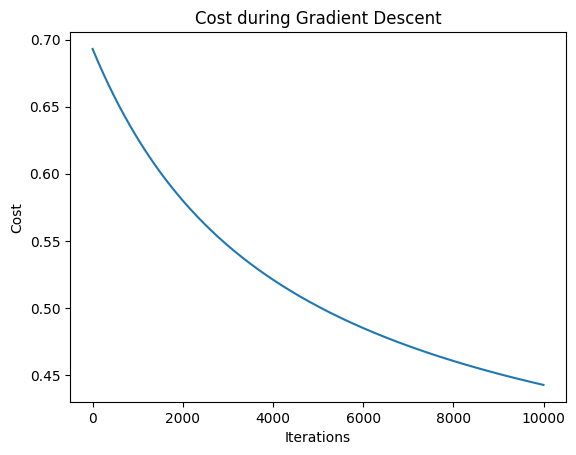

In [126]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost during Gradient Descent")
plt.show()